## Proyecto 1       Limpieza y Transformación de Datos de GreenMart

Claudio Grondona Pérez

# En primer lugar, hemos cargado el archivo .csv dentro de los archivos que gestiona este cuaderno de Google Collab.

# Una vez cargado pasamos a importar panda para poder ver correctamente el contenido en forma de dataframe (en adelante df).

# Con el comando "head" vemos las 5 primeras entradas y nos hacemos una idea del contenido, viendo el nombre de las columnas y los tipos de datos que podemos encontrarnos.

In [4]:
import pandas as pd

df = pd.read_csv("greenmart_customers_products.csv")

# Mostramos las 5 primeras filas.

df.head()

,customer_id,customer_name,age,city,product_id,product_name,category,purchase_date,purchase_quantity,price_per_unit,total_spent
0,1,Ronald Miller,63.0,Wilsonstad,141,Granola,Vegetable,2024-10-21,1.0,13.33,13.33
1,2,Eric White,26.0,North Brianside,172,Organic Apples,Vegetable,2024-08-15,2.0,1.04,2.08
2,3,Joseph Wagner,59.0,Lake Derek,186,Granola,Dairy,2024-07-16,1.0,15.33,15.33
3,4,Elizabeth House,43.0,Cindyborough,110,Granola,Snack,2024-09-18,1.0,10.55,10.55
4,5,Shawn Warner,56.0,North Hannah,147,Fresh Milk,Snack,2024-10-09,1.0,12.25,12.25


# Usamos "info" para obtener un vistazo general de lo que nos vamos a encontrar

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10400 entries, 0 to 10399
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        10400 non-null  int64  
 1   customer_name      9678 non-null   object 
 2   age                9678 non-null   float64
 3   city               9678 non-null   object 
 4   product_id         10400 non-null  int64  
 5   product_name       10400 non-null  object 
 6   category           10400 non-null  object 
 7   purchase_date      9678 non-null   object 
 8   purchase_quantity  9692 non-null   float64
 9   price_per_unit     10400 non-null  float64
 10  total_spent        9692 non-null   float64
dtypes: float64(4), int64(2), object(5)
memory usage: 893.9+ KB


# Tenemos 11 columnas y 10400 filas, de las cuales podemos ver bastantes nulos en algunas de ellas y que los tipos con los que vamos a trabajar son; int, float y objet, que es la manera de pandas de decir que tenemos strings o datos mixtos.


In [6]:
print(df["customer_name"].apply(type).unique())

[<class 'str'> <class 'float'>]


In [7]:
df[200:400]

,customer_id,customer_name,age,city,product_id,product_name,category,purchase_date,purchase_quantity,price_per_unit,total_spent
200,201,Stacy Brown,61.0,Lake Danielberg,130,Organic Apples,Snack,2024-01-01,2.0,17.25,34.50
201,202,Benjamin Padilla,28.0,West Joseph,175,Organic Apples,Snack,2024-09-08,4.0,16.41,65.64
202,203,William Perry,41.0,West Williammouth,109,Almond Butter,Dairy,2024-06-24,2.0,1.04,2.08
203,204,Mary Davis,49.0,Powellburgh,114,Tofu,Vegetable,2024-06-05,2.0,7.41,14.82
204,205,Emily Dalton,35.0,West Andrew,165,Almond Butter,Organic,2024-05-12,4.0,5.43,21.72
...,...,...,...,...,...,...,...,...,...,...,...
395,396,Kimberly Le,46.0,Reginaldshire,162,Kale,Snack,2024-03-08,3.0,17.07,51.21
396,397,Joseph Adams,20.0,Jamesstad,114,Organic Apples,Dairy,2024-09-04,3.0,4.99,14.97
397,398,NaN,NaN,NaN,187,Granola,Organic,NaN,NaN,1.06,NaN
398,399,Pamela Greene,79.0,Port Rebeccaview,173,Kale,Dairy,2024-06-28,2.0,16.05,32.10


# Me llama la atención que al pedir explicaciones sobre el contenido de la columna"customer_name" me diga que aparte de str contiene float.

# investigando he aprendido que se refiera a los "nan". Igualmente me aseguro de que no existan númmeros escondidos en los nombres.



In [8]:

numeros_reales = df[df["customer_name"].apply(lambda x: isinstance(x, float) and not pd.isna(x))]

numeros_reales

,customer_id,customer_name,age,city,product_id,product_name,category,purchase_date,purchase_quantity,price_per_unit,total_spent


# haciendo esta prueba puedo ver que al recibir un cuadro vacío, todos los nombres son str.

In [9]:
total_duplicados = df.duplicated().sum()
print(f"El conjunto de datos tiene {total_duplicados} filas duplicadas.")

El conjunto de datos tiene 367 filas duplicadas.


# Paso ahora a revisar los duplicados.

In [10]:

df[df.duplicated()]


,customer_id,customer_name,age,city,product_id,product_name,category,purchase_date,purchase_quantity,price_per_unit,total_spent
10000,9507,Tracy Jensen,46.0,West Jamesview,171,Organic Apples,Dairy,2024-06-01,4.0,18.66,74.64
10001,4621,Ariel Smith,75.0,Lake Colehaven,171,Tofu,Vegetable,2024-06-12,1.0,13.51,13.51
10002,3395,Kenneth Dean,66.0,Josephside,188,Fresh Milk,Vegetable,2024-01-29,3.0,12.83,38.49
10003,5288,Scott Holland,22.0,Lake Alicia,196,Organic Apples,Vegetable,2024-08-10,4.0,7.18,28.72
10004,8053,David Ochoa,44.0,West Shaun,194,Almond Butter,Organic,2024-04-15,3.0,9.56,28.68
...,...,...,...,...,...,...,...,...,...,...,...
10395,9745,Jeffrey Cantrell,28.0,Port Brenda,191,Kale,Organic,2024-05-16,1.0,15.82,15.82
10396,9251,Annette Flores,21.0,North Johnview,162,Almond Butter,Organic,2024-04-11,2.0,9.46,18.92
10397,8525,Christopher Ray,51.0,Reedville,186,Tofu,Vegetable,2024-04-01,2.0,6.51,13.02
10398,4929,Laura Ruiz,18.0,Leeview,125,Organic Apples,Organic,2024-09-27,2.0,2.03,4.06


In [11]:

duplicados_ejemplo = df[df.duplicated(keep=False)].sort_values(by=list(df.columns)[:3])
duplicados_ejemplo.head(10)


,customer_id,customer_name,age,city,product_id,product_name,category,purchase_date,purchase_quantity,price_per_unit,total_spent
17,18,Megan Charles,34.0,Richardville,140,Organic Apples,Dairy,2024-05-25,2.0,8.12,16.24
10195,18,Megan Charles,34.0,Richardville,140,Organic Apples,Dairy,2024-05-25,2.0,8.12,16.24
30,31,Stephanie Allen,50.0,South Andrew,183,Almond Butter,Snack,2024-01-10,1.0,12.90,12.90
10043,31,Stephanie Allen,50.0,South Andrew,183,Almond Butter,Snack,2024-01-10,1.0,12.90,12.90
45,46,Allen Parks,35.0,North Alexis,124,Almond Butter,Snack,2024-02-23,2.0,3.11,6.22
10376,46,Allen Parks,35.0,North Alexis,124,Almond Butter,Snack,2024-02-23,2.0,3.11,6.22
70,71,Shawn Khan,34.0,Aprilview,129,Fresh Milk,Vegetable,2024-05-02,4.0,16.00,64.00
10316,71,Shawn Khan,34.0,Aprilview,129,Fresh Milk,Vegetable,2024-05-02,4.0,16.00,64.00
109,110,Thomas Shaw,35.0,Calderonside,150,Almond Butter,Vegetable,2024-04-18,3.0,15.08,45.24
10349,110,Thomas Shaw,35.0,Calderonside,150,Almond Butter,Vegetable,2024-04-18,3.0,15.08,45.24


# Tengo un pequeño dilema aquí.   De 10400 filas, 367 son duplicados.  Al ser una tienda, no es imposible que un cliente compre dos veces lo mismo el mísmo día, algo que podríamos saber si tubiéramos numeración de la transacción o quizás hora de compra, sin embargo con los datos que tenemos y viendo que representa apenas un 3,5%  opto por eliminar los duplicados.

In [12]:

df = df.drop_duplicates()


print(f"Tamaño actual del conjunto de datos: {df.shape}")

Tamaño actual del conjunto de datos: (10033, 11)


# Además de los duplicados tenemos varios nombres "nulos", lo cual podría ser importante en ciertos casos, pero si lo que deseamos ver son las ventas el nombre del cliente  puede no tener tanto peso por lo tanto lo cambio a "desconocido" y así dejamos de tener nulos en nuestro campo "customer_name"

In [13]:

df["customer_name"] = df["customer_name"].fillna("Desconocido")

# Verifico si queda algún nulo.
print(f"Valores nulos restantes en customer_name: {df['customer_name'].isna().sum()}")

Valores nulos restantes en customer_name: 0


Pasamos a revisar las estadísticas descriptivas básicas para los campos numéricos.

In [14]:

df.describe()

,customer_id,age,product_id,purchase_quantity,price_per_unit,total_spent
count,10033.000000,9333.000000,10033.000000,9347.000000,10033.000000,9347.000000
mean,5001.158377,48.451516,149.770757,4.100995,13.428385,58.545593
std,2886.553347,17.919180,28.750215,15.792147,31.254202,808.101591
min,1.000000,18.000000,100.000000,1.000000,1.000000,1.000000
25%,2502.000000,33.000000,125.000000,1.000000,5.910000,11.255000
50%,4999.000000,48.000000,150.000000,3.000000,10.780000,20.970000
75%,7500.000000,64.000000,175.000000,4.000000,15.530000,38.820000
max,10000.000000,79.000000,199.000000,199.000000,499.350000,75475.350000


# A simple vista y sabiendp que tengo nulos que trabajar, podemos deducir:

*   La edad está comprendida entre 18 y 19 años.  Dato aceptable
*   La media de venta del tiket es de 58€ !! . Buena señal, retail rentable.
*   Al menos la mitad de los compradores se gasta 20€.
*   La media del precio por unidad es de 13,5 sin emabrgo la mediana es de 10,7
    lo cual nos da una idea de que en realidad la mayor cantidad de producto roza ese precio y que hay algunos con precios muy altos.


---



Paso ahora a revisar los nulos de cada columna. De los distintos métodos, la media y la mediana son los más usados en los casos numéricos.

# Por lo que hemos visto antes tenemos que arreglar las columnas de edad, ciudad, fecha de compra, cantidad de compra y total gastado.
cada una de estas columnas tendrá un tratamiento ajustado a la necesidad.

 *  age                9678 non-null   float64
 * city               9678 non-null   object
 * purchase_date      9678 non-null   object
 *  purchase_quantity  9692 non-null   float64
 *  total_spent        9692 non-null   float64

# Vamos a empezar por sustituir los nulos que sean STR  por "desconocido"

In [15]:
df["city"] = df["customer_name"].fillna("Desconocido")

# Verifico si queda algún nulo.
print(f"Valores nulos restantes en customer_name: {df['customer_name'].isna().sum()}")

Valores nulos restantes en customer_name: 0


# Para el caso de las Fechas, vamos a trabajar con "datetime", convertimos las fechas a este formato para poder ordenarlas, filtrar por meses y calcular antigüedades entre otras cosas.

In [16]:
df["purchase_date"] = pd.to_datetime(df["purchase_date"])

print(df["purchase_date"].dtype)

datetime64[ns]


In [17]:
#comprobamos nulos:

# Contar cuántas fechas en blanco hay
print(f"Fechas nulas: {df['purchase_date'].isna().sum()}")


Fechas nulas: 700


In [18]:
# vamos a ver qué pasó en esas fechas
df[df["purchase_date"].isna()].head(10)

,customer_id,customer_name,age,city,product_id,product_name,category,purchase_date,purchase_quantity,price_per_unit,total_spent
14,15,Desconocido,NaN,Desconocido,151,Tofu,Vegetable,NaT,NaN,13.60,NaN
37,38,Desconocido,NaN,Desconocido,148,Fresh Milk,Vegetable,NaT,NaN,9.19,NaN
47,48,Desconocido,NaN,Desconocido,135,Granola,Dairy,NaT,NaN,15.90,NaN
75,76,Desconocido,NaN,Desconocido,165,Tofu,Snack,NaT,NaN,6.51,NaN
98,99,Desconocido,NaN,Desconocido,168,Tofu,Snack,NaT,NaN,19.76,NaN
121,122,Desconocido,NaN,Desconocido,183,Almond Butter,Vegetable,NaT,NaN,18.10,NaN
135,136,Desconocido,NaN,Desconocido,143,Kale,Dairy,NaT,NaN,17.04,NaN
160,161,Desconocido,NaN,Desconocido,146,Organic Apples,Vegetable,NaT,NaN,14.61,NaN
171,172,Desconocido,NaN,Desconocido,118,Almond Butter,Dairy,NaT,NaN,5.48,NaN
173,174,Desconocido,NaN,Desconocido,127,Tofu,Dairy,NaT,NaN,2.41,NaN


# Qué interesante!  los datos con valor nulo no parecen ser totalmente aleatorios. Al ver qué fechas son nulas me he dado cuenta de que además son nulos prácticamente el resto de campos con peso estadístico.

Podríamos pasar por alto el nombre del comprador o su ciudad, pero en un informe para un departamento de ventas o para contabilidad los datos de "pursache_quiantity" y "total_spent" creo que son totalmente imprescindibles.

Hasta ahora había valorado sustiuir algunas de las cifras por medias o modas, sin embargo hacer eso con tantas columnas puede desvirtuar el resultado.

Ahora al carecer de solución puedo pasar a borrar directamente las filas con estos errores ( que son un 7% de datos, no es una decisión a la ligera, pero creo que es la más adecuada para el caso en concreto)


---





In [19]:
# Eliminar las filas donde 'total_spent' sea nulo
df = df.dropna(subset=["total_spent"])

# Verificar el estado actual de nuestro conjunto de datos
print(f"Tamaño del conjunto de datos tras la limpieza: {df.shape}")
print(f"Fechas nulas restantes: {df['purchase_date'].isna().sum()}")

Tamaño del conjunto de datos tras la limpieza: (9347, 11)
Fechas nulas restantes: 14


In [20]:
# revisamos las fechas "malas" restantes
df[df["purchase_date"].isna()].head(14)

,customer_id,customer_name,age,city,product_id,product_name,category,purchase_date,purchase_quantity,price_per_unit,total_spent
1491,1492,Desconocido,NaN,Desconocido,141,Kale,Dairy,NaT,153.0,7.80,1193.40
1998,1999,Desconocido,NaN,Desconocido,186,Granola,Organic,NaT,157.0,10.92,1714.44
3038,3039,Desconocido,NaN,Desconocido,143,Tofu,Dairy,NaT,186.0,2.71,504.06
3042,3043,Desconocido,NaN,Desconocido,198,Tofu,Vegetable,NaT,153.0,19.96,3053.88
3456,3457,Desconocido,NaN,Desconocido,134,Kale,Snack,NaT,195.0,15.41,3004.95
3617,3618,Desconocido,NaN,Desconocido,182,Almond Butter,Organic,NaT,186.0,17.85,3320.10
3786,3787,Desconocido,NaN,Desconocido,176,Granola,Dairy,NaT,111.0,15.68,1740.48
4192,4193,Desconocido,NaN,Desconocido,194,Almond Butter,Snack,NaT,108.0,11.28,1218.24
5619,5620,Desconocido,NaN,Desconocido,100,Tofu,Vegetable,NaT,114.0,4.19,477.66
7347,7348,Desconocido,NaN,Desconocido,148,Granola,Snack,NaT,194.0,3.38,655.72


# Vale, aquí siguen faltando nombre, edad , ciudad y fecha  Sin embargo los datos parecen seguir siendo "sospechosos".

En todos los casos restantes ( 14)  las cantidades de las compras son inusualmente altas.  (como vimos antes en nuestro informe rápido la media  es 4 y la mediana 3)  lo que nos indica que estos son casos muy atipicos, que alguien, teniendo fecha desconocida, comprador desconocido, de una ciudad desonocida y con edad desonocida ha comprado 3200 euros en leche...

Estoy bastante convencido de que estos datos son erroneos y paso a eliminarlos.

In [21]:
df = df.dropna(subset=["purchase_date"])

# volvemos a revisar
print(f"Tamaño del conjunto de datos tras la limpieza: {df.shape}")
print(f"Fechas nulas restantes: {df['purchase_date'].isna().sum()}")

Tamaño del conjunto de datos tras la limpieza: (9333, 11)
Fechas nulas restantes: 0


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9333 entries, 0 to 10394
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   customer_id        9333 non-null   int64         
 1   customer_name      9333 non-null   object        
 2   age                9333 non-null   float64       
 3   city               9333 non-null   object        
 4   product_id         9333 non-null   int64         
 5   product_name       9333 non-null   object        
 6   category           9333 non-null   object        
 7   purchase_date      9333 non-null   datetime64[ns]
 8   purchase_quantity  9333 non-null   float64       
 9   price_per_unit     9333 non-null   float64       
 10  total_spent        9333 non-null   float64       
dtypes: datetime64[ns](1), float64(4), int64(2), object(4)
memory usage: 875.0+ KB


# Ya no tengo nulos, pero el tema de las cantidades me ha llamado la atención y reviso en general cuales son las cantidades más altas de compras con todos los datos.

In [23]:
top_compras_altas = df.sort_values(by="purchase_quantity", ascending=False).head(90)

# busco coherencia
top_compras_altas[["customer_name", "price_per_unit", "purchase_quantity", "total_spent"]]

,customer_name,price_per_unit,purchase_quantity,total_spent
4935,Alejandro Tucker MD,4.92,199.0,979.08
10394,Brenda Perry MD,8.09,199.0,1609.91
5846,Tristan Cruz,19.95,198.0,3950.10
2731,Daniel Garner,15.55,198.0,3078.90
8183,Aimee Hill,4.92,197.0,969.24
...,...,...,...,...
8813,Carolyn Garrison,6.55,101.0,661.55
4406,Aaron Terry,4.81,4.0,19.24
1722,Brittany Perry,1.29,4.0,5.16
1723,Mary Martinez,12.75,4.0,51.00


# Hay al menos 96 compradores que hace compras de mas de 100 unidades. En principio no tiene por qué ser erroneo, pero me parece que es un dato a tener en cuenta.



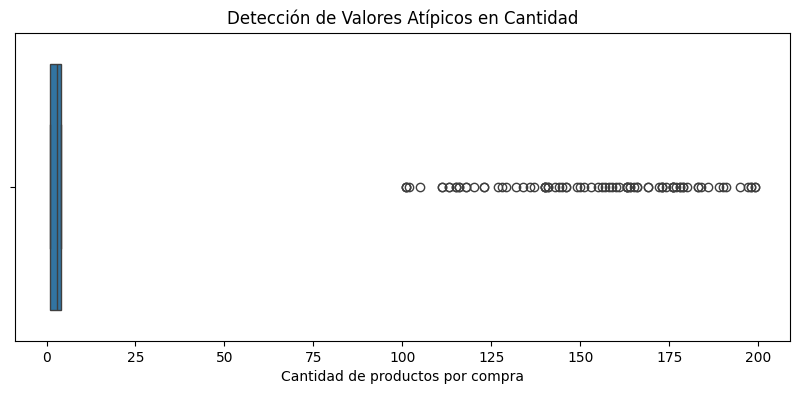

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 4))
sns.boxplot(x=df["purchase_quantity"])
plt.title("Detección de Valores Atípicos en Cantidad")
plt.xlabel("Cantidad de productos por compra")
plt.show()

#las compras normales quedan "espachurradas"

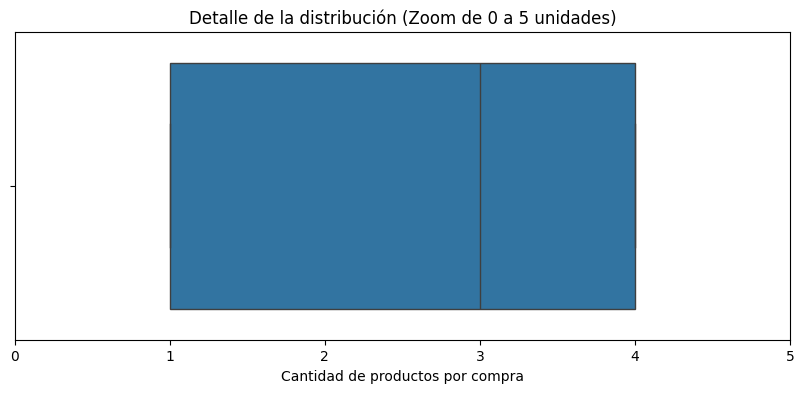

In [25]:
plt.figure(figsize=(10, 4))

sns.boxplot(x=df["purchase_quantity"])

plt.xlim(0, 5)

plt.title("Detalle de la distribución (Zoom de 0 a 5 unidades)")
plt.xlabel("Cantidad de productos por compra")
plt.show()

# Conclusión.   Podrían ser compras putuales de mayoristas.*texto en cursiva*

In [26]:
total_teorico = df["purchase_quantity"] * df["price_per_unit"]

df["diferencia_calculo"] = (df["total_spent"] - total_teorico).abs()

tolerancia = 0.05
descuadres = df[df["diferencia_calculo"] > tolerancia]


print(f"Número de filas con errores o descuadres de cálculo: {len(descuadres)}")

Número de filas con errores o descuadres de cálculo: 0


In [27]:
df = df.drop(columns=["diferencia_calculo"])
#borro la columna de prueba

In [28]:
columnas_texto = ["customer_name", "city", "product_name", "category"]

for col in columnas_texto:
    if col in df.columns:
        # Convertir todo el texto
        df[col] = df[col].str.lower()

        # Eliminar espacios
        df[col] = df[col].str.strip()

df[columnas_texto].head()

,customer_name,city,product_name,category
0,ronald miller,ronald miller,granola,vegetable
1,eric white,eric white,organic apples,vegetable
2,joseph wagner,joseph wagner,granola,dairy
3,elizabeth house,elizabeth house,granola,snack
4,shawn warner,shawn warner,fresh milk,snack


# No se en qué momento se ha superpuesto la columna nombre encima de ciudad. paso a arreglarlo.

In [29]:
df_original = pd.read_csv("greenmart_customers_products.csv")

# reemplazamos
df["city"] = df_original["city"]

# normalización
df["city"] = df["city"].str.lower().str.strip()

# rellenamos valores nulos
df["city"] = df["city"].fillna("desconocido")

# resultado
df[["customer_name", "city", "product_name", "category"]].head()

,customer_name,city,product_name,category
0,ronald miller,wilsonstad,granola,vegetable
1,eric white,north brianside,organic apples,vegetable
2,joseph wagner,lake derek,granola,dairy
3,elizabeth house,cindyborough,granola,snack
4,shawn warner,north hannah,fresh milk,snack


# Hecho esto creo que no queda nada importante que revisar y tenemos un archivo de datos listo para ser usado.

In [30]:

df.to_csv("datos_tienda_limpios.csv", index=False)

print("¡Archivo exportado correctamente en el entorno de Colab!")


¡Archivo exportado correctamente en el entorno de Colab!


Aunque no lo pide el ejercicio me gustaría saber qué artículos son los que se venden más.

/tmp/ipykernel_7897/1489006231.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


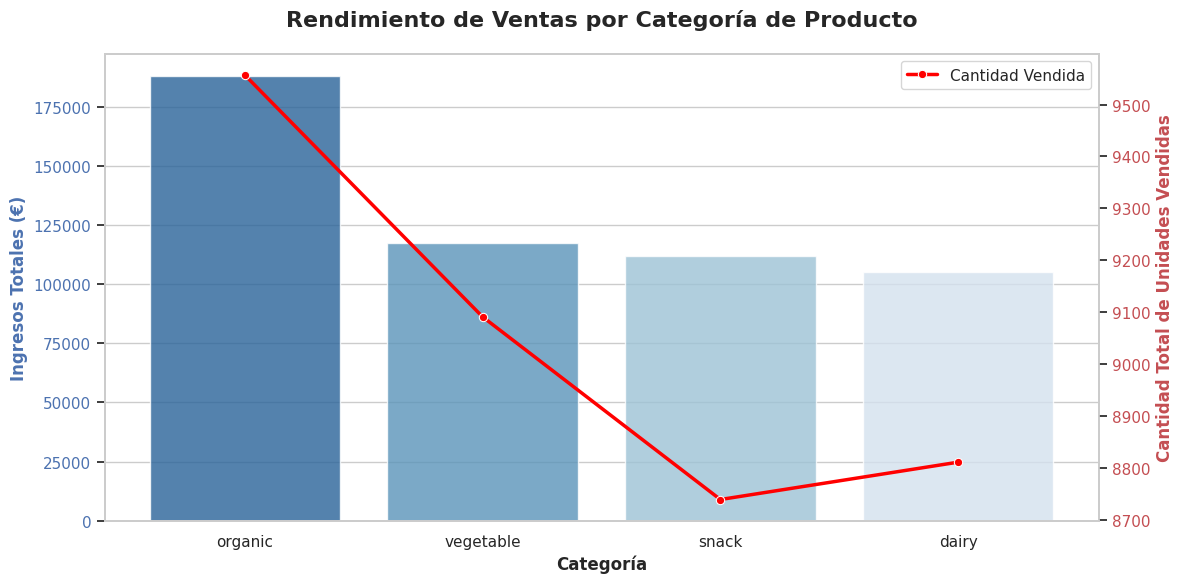

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Agrupar los datos por categoría para calcular el total gastado y la cantidad vendida
analisis_categorias = df.groupby("category").agg(
    ingresos_totales=("total_spent", "sum"),
    cantidad_total=("purchase_quantity", "sum")
).reset_index().sort_values(by="ingresos_totales", ascending=False)

# 2. Configurar el estilo del gráfico
sns.set_theme(style="whitegrid")
fig, ax1 = plt.subplots(figsize=(12, 6))

# 3. Dibujar las barras para los Ingresos Totales (Eje izquierdo)
sns.barplot(
    data=analisis_categorias,
    x="category",
    y="ingresos_totales",
    ax=ax1,
    palette="Blues_r",
    alpha=0.8
)
ax1.set_title("Rendimiento de Ventas por Categoría de Producto", fontsize=16, pad=20, fontweight="bold")
ax1.set_xlabel("Categoría", fontsize=12, fontweight="bold")
ax1.set_ylabel("Ingresos Totales (€)", fontsize=12, color="b", fontweight="bold")
ax1.tick_params(axis="y", labelcolor="b")

# 4. Crear un segundo eje para la Cantidad Vendida (Eje derecho)
ax2 = ax1.twinx()
sns.lineplot(
    data=analisis_categorias,
    x="category",
    y="cantidad_total",
    ax=ax2,
    color="red",
    marker="o",
    linewidth=2.5,
    label="Cantidad Vendida"
)
ax2.set_ylabel("Cantidad Total de Unidades Vendidas", fontsize=12, color="r", fontweight="bold")
ax2.tick_params(axis="y", labelcolor="r")
ax2.grid(False) # Evita que se mezclen las líneas de las cuadrículas

plt.tight_layout()
plt.show()

Está claro que lo orgánico es la fuente principal de este negocio, lo que más vende lo que más dinero genera.  Me llama la atención los Snacks. Producto que es evidentemente más caro ya que se vende menos pero genera el mismo dinero que vegetales o lacteos.

Si no tienen un lineal con más snacks en la caja de salida es lo primero que deben hacer!